# 02 — Modelling & Explainability
the goal is to train a baseline logistic regression and an XGBoost classifier on the German Credit dataset, compare them rigorously, tune the best candidate, and explain predictions with SHAP.

**Dataset:** UCI German Credit (id=144) — binary classification: good vs bad credit risk.

**Why AUC-ROC over accuracy?**  
The dataset is imbalanced (~70% good, ~30% bad). A naive classifier that always predicts "good" reaches ~70% accuracy while being completely useless. AUC-ROC measures the model's ability to *rank* bad customers above good ones across all thresholds — it's invariant to class imbalance and directly reflects discrimination power. Average Precision (PR-AUC) is even stricter: it focuses only on the positive (bad credit) class, penalising false negatives heavily — exactly the failure mode that costs a lender money.

## Setup ##


In [59]:
import sys, os
sys.path.append(os.path.abspath(".."))

import importlib
import src.preprocessing as prep
importlib.reload(prep)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib, json
from datetime import datetime

from ucimlrepo import fetch_ucirepo
from src.preprocessing import preprocess

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    recall_score, f1_score, make_scorer
)
import shap

RANDOM_STATE = 42
os.makedirs('models', exist_ok=True)

print("Python:", sys.executable)

Python: c:\Users\IqraRafiq\credit_risk_nl\env\Scripts\python.exe


## 1. Load & Preprocess

In [63]:
from ucimlrepo import fetch_ucirepo
from src.preprocessing import preprocess

ds = fetch_ucirepo(id=144)
X  = ds.data.features
y  = ds.data.targets.iloc[:, 0]

X_train, X_test, y_train, y_test = preprocess(
    X, y,  # keep all for now, SHAP will confirm later
    save_artifacts=True,
)

Input X shape: (1000, 20)
Input X columns: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']
Input X head:
   Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           67        A143        A152            2        A173            1   
1           22        A143        A152   

## 2. Baseline Models

Both models receive imbalance corrections *before* any tuning:
- **Logistic Regression** : `class_weight='balanced'` rescales sample weights inversely proportional to class frequencies.
- **XGBoost**: `scale_pos_weight = neg/pos` upweights the minority class in the gradient computation.

In [12]:
from ucimlrepo import fetch_ucirepo
from src.preprocessing import preprocess

ds = fetch_ucirepo(id=144)
X  = ds.data.features
y  = ds.data.targets.iloc[:, 0]

X_train, X_test, y_train, y_test = preprocess(
    X, y,  # keep all for now, SHAP will confirm later
    save_artifacts=True,
)

Input X shape: (1000, 20)
Input X columns: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']
Input X head:
   Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           67        A143        A152            2        A173            1   
1           22        A143        A152   

In [73]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
print("LR AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

LR AUC: 0.8033333333333333


In [ ]:
# XGBoost with imbalance handling
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=neg / pos,
    eval_metric="auc",
    random_state=42,
    base_score=0.5
)
xgb_model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)], verbose=False)
print("XGB AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

XGB AUC: 0.7911904761904761


## 3. Cross-Validated Comparison

A single train/test split is unreliable — one lucky shuffle can flip the ranking. We use **5-fold stratified cross-validation** to get stable estimates with confidence intervals.

Metrics:
- *AUC-ROC* : overall ranking ability
- *PR-AUC* :  precision-recall trade-off on the minority class
- *Recall* : fraction of bad customers correctly caught (critical: false negatives = approved bad loans)
- *F1*  : harmonic mean of precision and recall

In [67]:
# CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Class imbalance weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight = neg / pos

# Models
models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=pos_weight,
        eval_metric="auc",
        random_state=42
    )
}

# Proper scoring dictionary
scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "recall": make_scorer(recall_score),
    "f1": "f1"
}

results = {}

for name, model in models.items():
    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    results[name] = {
        "auc_mean": cv_scores["test_roc_auc"].mean(),
        "auc_std": cv_scores["test_roc_auc"].std(),

        "ap_mean": cv_scores["test_average_precision"].mean(),
        "ap_std": cv_scores["test_average_precision"].std(),

        "recall_mean": cv_scores["test_recall"].mean(),
        "recall_std": cv_scores["test_recall"].std(),

        "f1_mean": cv_scores["test_f1"].mean(),
        "f1_std": cv_scores["test_f1"].std(),

        "auc_scores": cv_scores["test_roc_auc"]
    }

    print(f"\n{name}")
    print(f"  AUC-ROC : {results[name]['auc_mean']:.4f} ± {results[name]['auc_std']:.4f}")
    print(f"  PR-AUC  : {results[name]['ap_mean']:.4f} ± {results[name]['ap_std']:.4f}")
    print(f"  Recall  : {results[name]['recall_mean']:.4f} ± {results[name]['recall_std']:.4f}")
    print(f"  F1      : {results[name]['f1_mean']:.4f} ± {results[name]['f1_std']:.4f}")


LogisticRegression
  AUC-ROC : 0.7782 ± 0.0442
  PR-AUC  : 0.6032 ± 0.0609
  Recall  : 0.6792 ± 0.0468
  F1      : 0.5723 ± 0.0392

XGBoost
  AUC-ROC : 0.7885 ± 0.0385
  PR-AUC  : 0.6100 ± 0.0653
  Recall  : 0.6458 ± 0.0493
  F1      : 0.6018 ± 0.0511


## 4. Tune XGBoost with GridSearchCV

Even if LR leads on recall, XGBoost has far more capacity to improve with tuning. We search over three key hyperparameters:
- `max_depth` — controls tree complexity / overfitting
- `n_estimators` — number of boosting rounds
- `learning_rate` — step size shrinkage

We optimise for **PR-AUC** (`average_precision`) — the most informative metric when the positive class is the class of interest and the dataset is imbalanced.

In [68]:
param_grid = {
    'max_depth':     [3, 4, 6],
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb_tuned = GridSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=pos_weight,
        eval_metric='auc',
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_tuned.fit(X_train, y_train)

print("\nBest params:", xgb_tuned.best_params_)
print(f"Best CV PR-AUC: {xgb_tuned.best_score_:.4f}")
print(f"Hold-out AUC : {roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:,1]):.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV PR-AUC: 0.6159
Hold-out AUC : 0.7983


## 5. Evaluation (comparing all three models)

We compare LR, XGBoost baseline, and XGBoost tuned using:
1. **ROC curve** = visualises the AUC trade-off
2. **Precision-Recall curve** = more informative for imbalanced problems
3. **Confusion matrix** = shows false negative rate directly

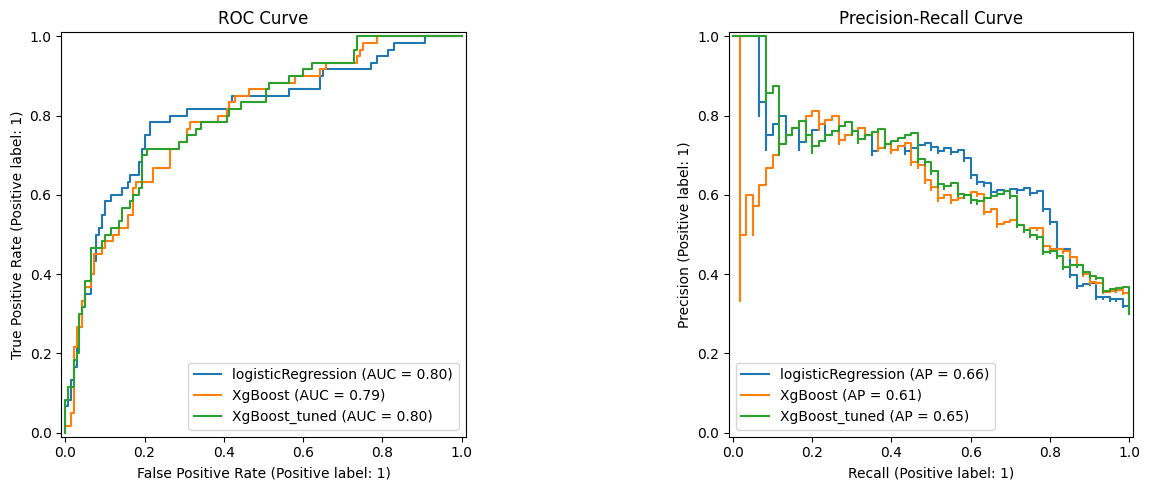

In [75]:
eval_models = {'logisticRegression' : lr,
               'XgBoost' : xgb_model,
               'XgBoost_tuned' : xgb_tuned,

}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in eval_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[1])

axes[0].set_title('ROC Curve')
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.savefig('models/roc_pr_curves.png', dpi=150)
plt.show()

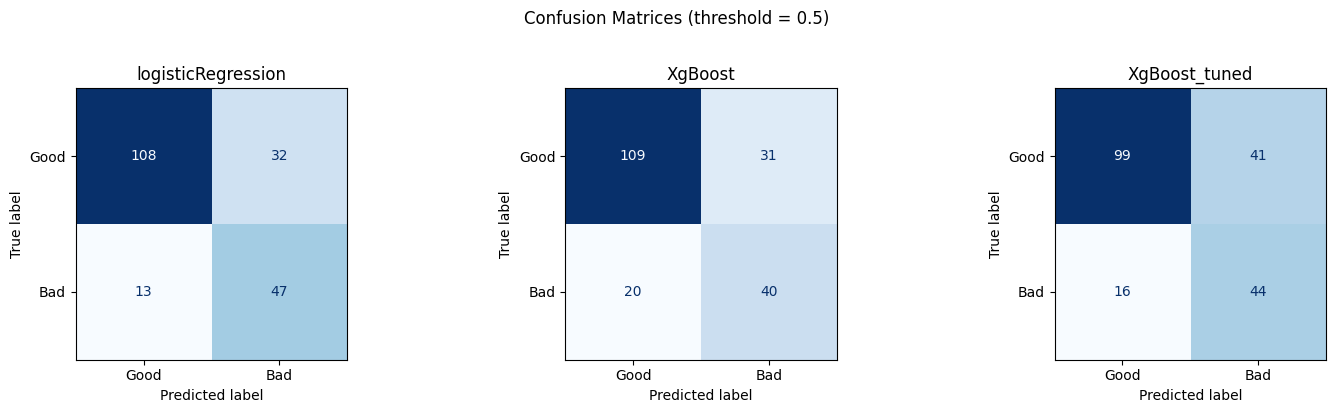

In [76]:
# Confusion matrices at default 0.5 threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, eval_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good', 'Bad'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices (threshold = 0.5)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('models/confusion_matrices.png', dpi=150)
plt.show()

Here false positive is important and losgistic regression predicts less that validate my findings above selecting logistics regressions

In [77]:
# Summary table
summary = []
for name, model in eval_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    summary.append({
        'Model':     name,
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC':    round(average_precision_score(y_test, y_prob), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
})

summary_df = pd.DataFrame(summary).set_index('Model')
print(summary_df.to_string())

                    AUC-ROC  PR-AUC  Recall      F1
Model                                              
logisticRegression   0.8033  0.6624  0.7833  0.6763
XgBoost              0.7912  0.6117  0.6667  0.6107
XgBoost_tuned        0.7983  0.6519  0.7333  0.6069


In [78]:
# Update chosen_name and final_model based on your summary_df results
chosen_name = summary_df['Recall'].idxmax()  # auto-select highest recall
final_model  = eval_models[chosen_name]

print(f"Selected model: {chosen_name}")
print(summary_df.loc[chosen_name])

Selected model: logisticRegression
AUC-ROC    0.8033
PR-AUC     0.6624
Recall     0.7833
F1         0.6763
Name: logisticRegression, dtype: float64


## 7. SHAP 

SHAP (SHapley Additive exPlanations) attributes each prediction to individual features in a theoretically grounded way. We generate:
1. **Beeswarm plot** — global feature importance across all test samples
2. **Waterfall plot** — granular explanation for a single prediction

> There are two ways were studied: `TreeExplainer` is used for XGBoost (exact, fast). `LinearExplainer` is used for Logistic Regression.

In [80]:
explainer = shap.LinearExplainer(final_model, X_train)
shap_vals = explainer.shap_values(X_test)
shap_explanation = explainer(X_test)
print(f"SHAP values shape: {np.array(shap_vals).shape}")

SHAP values shape: (200, 44)


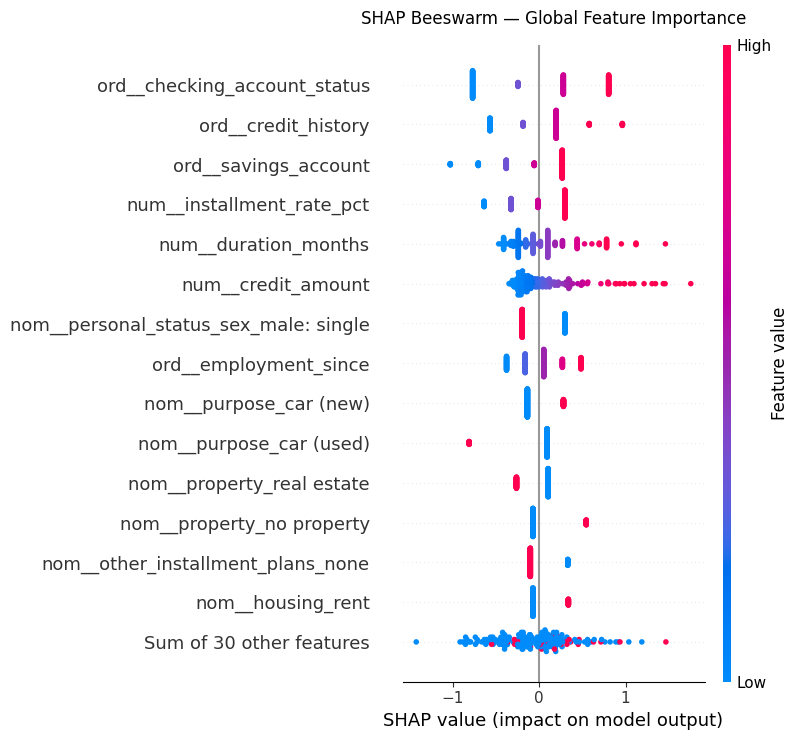

In [82]:
# Global feature importance — beeswarm
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title('SHAP Beeswarm — Global Feature Importance', pad=15)
plt.tight_layout()
plt.savefig('models/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

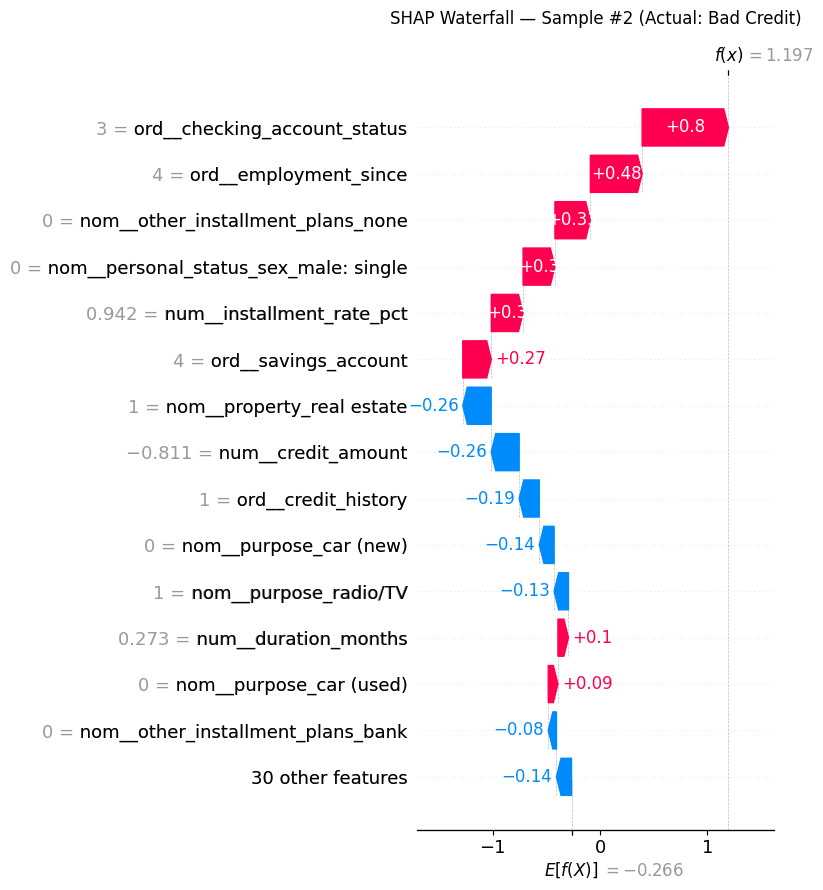

Predicted probability of bad credit: 0.768


In [83]:
# Single prediction explanation — waterfall
# Pick a bad-credit example from test set for a more interesting explanation
bad_idx = np.where(y_test.values == 1)[0][0]

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[bad_idx], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Sample #{bad_idx} (Actual: Bad Credit)', pad=15)
plt.tight_layout()
plt.savefig('models/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Predicted probability of bad credit: {final_model.predict_proba(X_test.iloc[[bad_idx]])[:,1][0]:.3f}")

## 8. Save Best Model & Metadata

We serialise the final model and attach structured metadata for reproducibility and production handoff.

In [84]:
model_path = 'models/best_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model saved → {model_path}")

# If XGBoost, also save in native format
if 'XGBoost' in chosen_name:
    xgb_path = 'models/xgb_best.pkl'
    joblib.dump(final_model, xgb_path)
    print(f"XGBoost model also saved → {xgb_path}")

Model saved → models/best_model.pkl


In [85]:
import sklearn

y_prob_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = final_model.predict(X_test)

metadata = {
    'model_type':           chosen_name,
    'trained_at':           datetime.now().isoformat(),

    # PRIMARY DECISION METRIC
    'selection_metric':     'recall',
    'selection_reason':     (
        'Recall maximised to minimise false negatives '
        '(approved bad-credit customers). Business cost of '
        'FN >> FP in credit-risk context.'
    ),

    # Hold-out performance
    'holdout_auc_roc':      round(roc_auc_score(y_test, y_prob_final), 4),
    'holdout_pr_auc':       round(average_precision_score(y_test, y_prob_final), 4),
    'holdout_recall':       round(recall_score(y_test, y_pred_final), 4),
    'holdout_f1':           round(f1_score(y_test, y_pred_final), 4),

    'optimal_threshold':    0.5,  # tune this with precision_recall_curve if needed

    'features_used':        X_train.columns.tolist(),
    'n_features':           X_train.shape[1],
    'train_size':           int(X_train.shape[0]),
    'test_size':            int(X_test.shape[0]),

    'dataset':              'German Credit (UCI id=144)',
    'target_encoding':      '1 = bad credit (positive class), 0 = good credit',
    'class_imbalance_ratio': round(float(neg / pos), 2),

    'sklearn_version':      sklearn.__version__,
    'xgboost_version':      xgb.__version__,
}

metadata_path = 'models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved → {metadata_path}")
print(json.dumps({k: v for k, v in metadata.items() if k != 'features_used'}, indent=2))

Metadata saved → models/model_metadata.json
{
  "model_type": "logisticRegression",
  "trained_at": "2026-05-04T16:06:04.786777",
  "selection_metric": "recall",
  "selection_reason": "Recall maximised to minimise false negatives (approved bad-credit customers). Business cost of FN >> FP in credit-risk context.",
  "holdout_auc_roc": 0.8033,
  "holdout_pr_auc": 0.6624,
  "holdout_recall": 0.7833,
  "holdout_f1": 0.6763,
  "optimal_threshold": 0.5,
  "n_features": 44,
  "train_size": 800,
  "test_size": 200,
  "dataset": "German Credit (UCI id=144)",
  "target_encoding": "1 = bad credit (positive class), 0 = good credit",
  "class_imbalance_ratio": 2.33,
  "sklearn_version": "1.8.0",
  "xgboost_version": "3.2.0"
}


## Summary

| Step | What we did |
|------|-------------|
| **Data** | UCI German Credit — binary, imbalanced (~70/30) |
| **Baseline** | LR + balanced weights, XGBoost + scale_pos_weight |
| **Comparison** | 5-fold CV: AUC, PR-AUC, Recall, F1 |
| **Tuning** | GridSearchCV on XGBoost: max_depth × n_estimators × learning_rate |
| **Evaluation** | ROC curve, PR curve, confusion matrix — all three models |
| **Explainability** | SHAP beeswarm (global) + waterfall (single prediction) |
| **Deployment** | Model serialised to `models/best_model.pkl`, metadata to JSON |

**Key insight:** AUC and accuracy can be misleading on imbalanced data. Recall on the bad-credit class is the metric that maps directly to business loss. Always validate on cross-validation, not a single split.